In [ ]:
using LinearAlgebra
using BSplineKit
using SparseArrays
using Plots
using ProgressMeter

In [135]:
include("LST_BEK copy.jl")

Main.io

In [ ]:
N=49
    baseflow=("Vonkarmen.txt")        
    θ = range(0,length=N+1,stop=pi)
    x = reshape(-cos.(θ), N+1, 1)
    c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
    X = repeat(x, 1, N+1);
    dX = X - X';
    D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
    D = D - diagm(vec(sum(D, dims=2))); 
    #interpolation
    f = open( baseflow, "r" )
    n = countlines( f )
    seekstart( f )
    data = zeros(n,6)
    for i = 1:n
        z,w,u,v,du,dv = split( readline( f ), " " ) 
        data[i,1] = parse(Float64,z)
        data[i,2] = parse(Float64,w)
        data[i,3] = parse(Float64,u)
        data[i,4] = parse(Float64,v)  
        data[i,5] = parse(Float64,du)
        data[i,6] = parse(Float64,dv)
    end

    close( f )
    t=data[:,1]
    w=data[:,2]
    u=data[:,3]
    v=data[:,4]
    du=data[:,5]
    dv=data[:,6]
    itpw=itp = interpolate(t, w , BSplineOrder(4))
    itpu=itp = interpolate(t, u , BSplineOrder(4))
    itpv=itp = interpolate(t, v , BSplineOrder(4))
    itpdu=itp = interpolate(t, du , BSplineOrder(4))
    itpdv=itp = interpolate(t, dv , BSplineOrder(4))
    for i=1:N+1
        D[i,:]=D[i,:].*((2*x[i]^3-x[i]^2+3*x[i]-4)^2/(20*(6*x[i]^2-2*x[i]+3)))
    end
    for i=1:N+1
        x[i]=(4*x[i]^3-2*x[i]^2+6*x[i]+12)/(-2*x[i]^3+x[i]^2-3*x[i]+4)
        if x[i]>50
            x[i]=50
        end
    end
            D2=D^2;
            U=zeros(N+1,1)
            V=zeros(N+1,1)
            W=zeros(N+1,1)
            dU=zeros(N+1,1)
            dV=zeros(N+1,1)
            dW=zeros(N+1,1)
            p=zeros(N+1,1)
            for i=1:N+1
                U[i,1]=itpu(x[i])
                V[i,1]=itpv(x[i])
                W[i,1]=itpw(x[i])
                dU[i,1]=itpdu(x[i])
                dV[i,1]=itpdv(x[i])
            end
            dW=-2*U
            ddU=D*dU;
            ddV=D*dV;


In [ ]:
 function rayleigh_quotient_iteration(A, B, sigma, q0=rand(size(A, 1), 1))

    flg = true
    while flg
        sigma0 = sigma[1]+ 0.0e0im
        q = (A - sigma.*B) \ (B*q0)
        q0 = q/maximum(abs.(q))
        sigma = ((q0'*(A*q0))/(q0'*(B*q0)))[1]
        if abs(sigma-sigma0)<=eps(1.0f0)
            flg = false
        end

    end

      return sigma, q0
    end

In [ ]:
function iter_arr(center_point,x_0,x_1,delta)
    array = [center_point]
    x = center_point
    step1 = round(abs(center_point-x_0)/delta)
    step2 = round(abs(center_point-x_1)/delta)
    for i = 1 : step1
        x = center_point-i*delta
        push!(array,x)
    end
    push!(array,center_point)
    for i = 1 : step2
        x = center_point+i*delta
        push!(array,x)
    end
    return array
    end

In [136]:
function timemode(R,alpha,beta)
    lamda = sqrt(alpha^2+beta^2)
    A11 = im*alpha*U.*I(N+1)+im*beta*V.*I(N+1)-(1/R)*(D^2-lamda^2 .*I(N+1)-W.*D)
    A12 = -(1/R)*(2*(V.+1).*I(N+1))
    A13 = dU .* I(N+1)
    A14 = im*alpha * I(N+1)
    A21 = (1/R)*2*(V.+1).*I(N+1)
    A22 = im*alpha*U.*I(N+1)+im*beta*V.*I(N+1)-(1/R)*(D^2-lamda^2 .*I(N+1)-W.*D)
    A23 = dV.*I(N+1)
    A24 = im*beta * I(N+1)
    A31 = zeros(N+1,N+1)
    A32 = zeros(N+1,N+1)
    A33 = im*alpha*U.*I(N+1)+im*beta*V.*I(N+1)-(1/R)*(D^2-lamda^2 .*I(N+1)-W.*D-dW.*I(N+1))
    A34 = D
    A41 = im*alpha*I(N+1)+(1/R)*I(N+1)
    A42 = im*beta*I(N+1)
    A43 = D
    A44 = zeros(N+1,N+1)
    B11 = im*I(N+1)
    B12 = B13 = B14 = zeros(N+1,N+1)
    B22 = im*I(N+1)
    B21 = B23 = B24 = zeros(N+1,N+1)
    B33 = im*I(N+1)
    B31 = B32 = B34 = zeros(N+1,N+1)
    B41 = B42 = B43 = B44 = zeros(N+1,N+1)
    A = [A11 A12 A13 A14;A21 A22 A23 A24;A31 A32 A33 A34;A41 A42 A43 A44]
    B = [B11 B12 B13 B14;B21 B22 B23 B24;B31 B32 B33 B34;B41 B42 B43 B44]
    A=A[setdiff(1:end , (1,N+1,N+2,2N+2,2N+3,3N+3)),setdiff(1:end , (1,N+1,N+2,2N+2,2N+3,3N+3))]
    B=B[setdiff(1:end , (1,N+1,N+2,2N+2,2N+3,3N+3)),setdiff(1:end , (1,N+1,N+2,2N+2,2N+3,3N+3))]
    return A,B
end

timemode (generic function with 1 method)

In [237]:
R = 600
data1 = empty!
beta = 0.1
@showprogress for alpha = 0.0025:0.0025:0.8
    A,B = KEB_TimeMode.KEB_LST_all("Vonkarmen.txt",N,alpha,beta,R,1,2)
    C = eigen(A,B)
    value = C.values
    h = filter(x->0<imag(x)<0.008 && -0.1<real(x)<0.1,value)
    if h == []
        val = 0
    else
        r=findmin(x-> abs.( x -imag(data1[end,1])),imag(h))
        val = r[1]
    end
    # Arr = [alpha beta val]
    data1 = [data1;val]
end

In [232]:
R = 600
alpha = 0.59
beta = 0.1
A,B = KEB_TimeMode.KEB_LST_all("Vonkarmen.txt",N,alpha,beta,R,1,2)
C = eigen(A,B)
value = C.values
h = filter(x->0<imag(x)<0.008 && -0.1<real(x)<0.1,value)

2-element Vector{ComplexF64}:
 -4.956567716288252e-5 + 0.007463130904312401im
  0.009851382848973902 + 0.0021410908718411236im

In [236]:
r=findmin(x-> abs.( x -imag(data1[end,1])),imag(h))


(0.005057270943276207, 1)

In [240]:
data1[266:end,1] .= 0

55-element view(::Matrix{Any}, 266:320, 1) with eltype Any:
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 ⋮
 0
 0
 0
 0
 0
 0
 0
 0
 0

In [238]:
data1 = data1[2:end,:]

320×1 Matrix{Any}:
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 ⋮
 0.005273287306669719
 0.0052461550693865796
 0.005219060436432306
 0.005192003202944236
 0.0051649831652993685
 0.005138000121093974
 0.005111053869147072
 0.005084144209470743
 0.005057270943276207

In [241]:
data = [data data1]

320×6 Matrix{Any}:
 0.0025  0.1  0.0  0  0  0
 0.005   0.1  0.0  0  0  0
 0.0075  0.1  0.0  0  0  0
 0.01    0.1  0.0  0  0  0
 0.0125  0.1  0.0  0  0  0
 0.015   0.1  0.0  0  0  0
 0.0175  0.1  0.0  0  0  0
 0.02    0.1  0.0  0  0  0
 0.0225  0.1  0.0  0  0  0
 0.025   0.1  0.0  0  0  0
 ⋮                       ⋮
 0.78    0.1  0.0  0  0  0
 0.7825  0.1  0.0  0  0  0
 0.785   0.1  0.0  0  0  0
 0.7875  0.1  0.0  0  0  0
 0.79    0.1  0.0  0  0  0
 0.7925  0.1  0.0  0  0  0
 0.795   0.1  0.0  0  0  0
 0.7975  0.1  0.0  0  0  0
 0.8     0.1  0.0  0  0  0

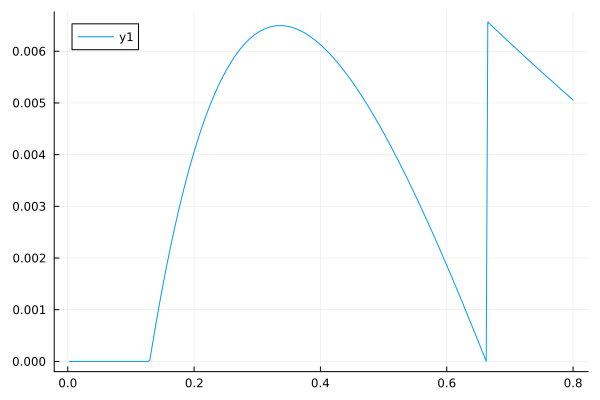

In [239]:
plot(data[:,1],data1[:,1])

In [242]:
using DelimitedFiles
writedlm("von_incompress.dat",data,'\t')